   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
import json
import random
import pandas as pd

# ============================================================
# BASE PATTERNS
# ============================================================

import json
import random
import pandas as pd

# ============================================================
# CLEAR & FOCUSED PATTERNS
# ============================================================

ORDER_STATUS_PATTERNS = [
    # Clean patterns
    "orderan saya kemana",
    "cek pesanan {order_id}",
    "status order {order_id}",
    "pesanan nomor {order_id} udah sampai mana",
    "order {order_id} udah nyampe belum",
    "tracking pesanan {order_id}",
    "gimana kabar orderan saya",
    "mau cek status pesanan dong",

    # Natural variations
    "pesanan saya {order_id} udah nyampe blm ya kak",
    "cek order {order_id} dong min",
    "mau tau status order {order_id} gmn caranya",
    "halo, order {order_id} udh diproses blm?",
    "permisi kak orderan {order_id} kok blm dateng",
    "track pesanan {order_id}",
    "{order_id} statusnya apa ya",

    # Casual/slang (but still clear intent)
    "order gue {order_id} mana ya",
    "pesanan gw {order_id} kmn",
    "kok barang {order_id} lama bgt",
    "brg {order_id} blm dateng2",
    "udah dikirim blom {order_id}",
    "cekin order {order_id} dong",
    "ke mana nih barang {order_id}",

    # Without order_id (general inquiry)
    "gimana cara cek status pesanan",
    "mau track order saya",
    "orderan saya udah dikirim belum",
    "barang saya udah sampai mana",
    "cek status pengiriman dong",
]

PAYMENT_PATTERNS = [
    # Clean patterns
    "metode pembayaran apa aja",
    "bisa bayar pakai {payment_method}",
    "payment method yang tersedia",
    "cara bayarnya gimana",
    "accept {payment_method} ga",
    "pembayaran pakai apa aja",

    # Natural variations
    "terima pembayaran {payment_method} ga?",
    "bisa pake {payment_method} ga sih",
    "{payment_method} bisa digunakan?",
    "pembayaran lewat {payment_method} ada?",
    "support {payment_method}?",
    "ada metode {payment_method}?",

    # General payment questions
    "pembayaran apa yang diterima",
    "cara bayar gimana ya",
    "metode payment apa saja",
    "bisa bayar pakai e-wallet?",
    "terima transfer bank ga?",
    "cod tersedia?",

    # Casual/slang
    "bayar pake apa sih",
    "pembayaran gimn",
    "gopay bisa ga sih",
    "pake qris ada?",
    "bayar cash bs?",
    "metode byr apa aja",
    "support pembayaran apa",
]

PRODUCT_PATTERNS = [
    # Clean patterns
    "harga {product_name}",
    "stock {product_name} masih ada",
    "info produk {product_name}",
    "{product_name} harganya berapa",
    "detail {product_name}",
    "spesifikasi {product_name}",

    # Natural variations
    "berapa harga {product_name}",
    "ada {product_name} ga",
    "{product_name} ready stock?",
    "stok {product_name} ada?",
    "{product_name} masih tersedia?",
    "mau tanya harga {product_name}",
    "cari {product_name} ada ga",
    "{product_name} specs nya gimana",

    # Casual/slang
    "brp harga {product_name}",
    "{product_name} ready?",
    "yang {product_name} ada stok?",
    "{product_name} msh ada?",
    "ada ga barang {product_name}",
    "stok {product_name} ad g",
    "hrg {product_name} brp",

    # General product inquiry
    "ada produk apa aja",
    "mau liat katalog",
    "barang apa yang tersedia",
]

# ============================================================
# ENTITIES
# ============================================================

ORDER_IDS = [
    "12345", "67890", "ORD001", "#12345", "nomor 999",
    "no.1234", "id 7788", "order-5566", "998877",
    "pesanan 4444", "1122", "99887"
]

PAYMENT_METHODS = [
    "gopay", "ovo", "dana", "transfer bank",
    "cod", "credit card", "debit", "virtual account",
    "qris", "shopee pay", "link aja"
]

PRODUCT_NAMES = [
    "sepatu", "baju", "celana", "tas", "laptop",
    "hp", "kaos", "topi", "kemeja", "jam tangan",
    "headset", "mouse", "keyboard", "charger"
]

# ============================================================
# PREFIXES & SUFFIXES
# ============================================================

PREFIXES = ["", "halo", "permisi", "min", "kak", "gan", "misi"]
SUFFIXES = ["", "dong", "ya", "pls", "tolong", "thanks"]

# ============================================================
# NOISE FUNCTIONS (CONTROLLED)
# ============================================================

def introduce_typo(text, prob=0.2):
    """Add typo with probability"""
    if random.random() > prob or len(text) < 5:
        return text

    words = text.split()
    if not words:
        return text

    # Typo in one random word
    word_idx = random.randint(0, len(words) - 1)
    word = words[word_idx]

    if len(word) > 2:
        char_idx = random.randint(0, len(word) - 1)
        word = word[:char_idx] + word[char_idx+1:]  # Remove one char

    words[word_idx] = word
    return " ".join(words)

def wrap_casual(text, prob=0.3):
    """Add casual prefix/suffix"""
    if random.random() > prob:
        return text

    prefix = random.choice(PREFIXES)
    suffix = random.choice(SUFFIXES)

    if prefix:
        text = f"{prefix} {text}"
    if suffix:
        text = f"{text} {suffix}"

    return text.strip()

def add_noise(text):
    """Apply controlled noise"""
    # Basic variations
    variations = [
        text,
        text.lower(),
        text.capitalize(),
    ]

    text = random.choice(variations)

    # Add typo (20% chance)
    text = introduce_typo(text, prob=0.15)

    # Add casual wrapper (30% chance)
    text = wrap_casual(text, prob=0.25)

    # Add punctuation (30% chance)
    if random.random() < 0.3:
        text += random.choice(["?", ""])

    return text

# ============================================================
# GENERATOR
# ============================================================

def generate_variations(patterns, entities, intent_label, num_samples=500):
    data = []

    for _ in range(num_samples):
        pattern = random.choice(patterns)

        # Replace placeholders
        if "{order_id}" in pattern:
            pattern = pattern.replace("{order_id}", random.choice(entities["order_ids"]))

        if "{payment_method}" in pattern:
            pattern = pattern.replace("{payment_method}", random.choice(entities["payment_methods"]))

        if "{product_name}" in pattern:
            pattern = pattern.replace("{product_name}", random.choice(entities["product_names"]))

        # Apply noise
        text = add_noise(pattern)

        data.append({
            "text": text,
            "intent": intent_label
        })

    return data

# ============================================================
# GENERATE DATASET
# ============================================================

print("🔄 Generating synthetic dataset...\n")

dataset = []

# Generate 500 samples per intent
dataset.extend(generate_variations(
    ORDER_STATUS_PATTERNS,
    {"order_ids": ORDER_IDS, "payment_methods": PAYMENT_METHODS, "product_names": PRODUCT_NAMES},
    "order_status",
    500
))

dataset.extend(generate_variations(
    PAYMENT_PATTERNS,
    {"order_ids": ORDER_IDS, "payment_methods": PAYMENT_METHODS, "product_names": PRODUCT_NAMES},
    "payment_info",
    500
))

dataset.extend(generate_variations(
    PRODUCT_PATTERNS,
    {"order_ids": ORDER_IDS, "payment_methods": PAYMENT_METHODS, "product_names": PRODUCT_NAMES},
    "product_info",
    500
))

# Shuffle
random.shuffle(dataset)

# Save
df = pd.DataFrame(dataset)
df.to_csv('data/synthetic/intent_dataset.csv', index=False)

print(f"✅ Generated {len(dataset)} samples")
print(f"\n📊 Distribution:")
print(df['intent'].value_counts())

# Show samples
print(f"\n📝 Sample data:")
for intent in ['order_status', 'payment_info', 'product_info']:
    print(f"\n{intent.upper()}:")
    samples = df[df['intent'] == intent]['text'].head(3).tolist()
    for s in samples:
        print(f"  - {s}")


🔄 Generating synthetic dataset...

✅ Generated 1500 samples

📊 Distribution:
intent
order_status    500
payment_info    500
product_info    500
Name: count, dtype: int64

📝 Sample data:

ORDER_STATUS:
  - Cek pesanan 67890
  - mau tau status order 12345 gmn caranya dong
  - order 67890 udah nyampe belum?

PAYMENT_INFO:
  - misi pembayaran gimn tolong?
  - misi support virtual account? thanks
  - Bayar cash bs?

PRODUCT_INFO:
  - kak Stok keyboard ad g
  - halo Info produk keyboard thanks
  - min Spesifikasi baju dong


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import numpy as np

print("🚀 Intent Classification Training\n")

# Load data
df = pd.read_csv('data/synthetic/intent_dataset.csv')
df = df.dropna()
df = df[df['text'].str.len() > 0]

print(f"✅ Total: {len(df)}")
print(f"\n📊 Distribution:\n{df['intent'].value_counts()}")

# Labels
label2id = {"order_status": 0, "payment_info": 1, "product_info": 2}
id2label = {v: k for k, v in label2id.items()}
df['label'] = df['intent'].map(label2id)

# Split
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\n✂️  Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Model & Tokenizer
MODEL_NAME = "cahya/distilbert-base-indonesian"
print(f"\n🤖 Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Tokenize
print("\n🔤 Tokenizing...")

train_encodings = tokenizer(
    train_df['text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors=None
)

val_encodings = tokenizer(
    val_df['text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors=None
)

test_encodings = tokenizer(
    test_df['text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors=None
)

# Create datasets
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_df['label'].tolist()
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': val_df['label'].tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_df['label'].tolist()
})

print("✅ Datasets ready")

# 🔥 TRAINING ARGUMENTS - NO EVALUATION DURING TRAINING!
training_args = TrainingArguments(
    output_dir="./models/intent_classifier",
    eval_strategy="no",  # 🔥 DISABLE evaluation during training
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    save_total_limit=2,
    logging_steps=10,
    report_to="none",
)

# Trainer - NO compute_metrics
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
    # NO compute_metrics, NO eval_dataset during training
)

# Train
print("\n" + "="*60)
print("🚀 STARTING TRAINING (No evaluation during training)")
print("="*60 + "\n")

trainer.train()

print("\n✅ Training complete!")

# ==========================================
# MANUAL EVALUATION
# ==========================================
print("\n" + "="*60)
print("📊 MANUAL EVALUATION")
print("="*60)

model.eval()
import torch

def evaluate_dataset(dataset, name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    all_preds = []
    all_labels = []

    print(f"\nEvaluating {name} set...")

    for i in range(len(dataset)):
        item = dataset[i]

        input_ids = torch.tensor([item['input_ids']]).to(device)
        attention_mask = torch.tensor([item['attention_mask']]).to(device)
        label = item['labels']

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred = torch.argmax(outputs.logits, dim=-1).item()

        all_preds.append(pred)
        all_labels.append(label)

    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    print(f"✅ {name} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    return accuracy, all_preds, all_labels

# Evaluate
val_acc, val_preds, val_labels = evaluate_dataset(val_dataset, "Validation")
test_acc, test_preds, test_labels = evaluate_dataset(test_dataset, "Test")

# Detailed metrics
from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "="*60)
print("📊 DETAILED TEST RESULTS")
print("="*60 + "\n")

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=list(label2id.keys())))

print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_preds)
print(cm)

# Save model
print("\n💾 Saving model...")
trainer.save_model("./models/intent_classifier/best_model")
tokenizer.save_pretrained("./models/intent_classifier/best_model")

import json
with open("./models/intent_classifier/best_model/label_mapping.json", 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2)

# Save test results
test_results_df = pd.DataFrame({
    'text': test_df['text'].tolist(),
    'true_label': [id2label[l] for l in test_labels],
    'predicted_label': [id2label[p] for p in test_preds],
    'correct': [t == p for t, p in zip(test_labels, test_preds)]
})
test_results_df.to_csv('./models/intent_classifier/test_results.csv', index=False)

print("\n" + "="*60)
print("✅ ALL DONE!")
print("="*60)
print(f"\n📁 Model: ./models/intent_classifier/best_model")
print(f"🎯 Val Accuracy: {val_acc*100:.2f}%")
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"📊 Results: ./models/intent_classifier/test_results.csv")

🚀 Intent Classification Training

✅ Total: 1500

📊 Distribution:
intent
order_status    500
payment_info    500
product_info    500
Name: count, dtype: int64

✂️  Split: Train=1050, Val=225, Test=225

🤖 Loading cahya/distilbert-base-indonesian...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at cahya/distilbert-base-indonesian and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🔤 Tokenizing...
✅ Datasets ready


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.



🚀 STARTING TRAINING (No evaluation during training)



Step,Training Loss
10,1.049500
20,0.760400
30,0.419100
40,0.172900
50,0.063500
60,0.028800
70,0.012500
80,0.007600
90,0.011000
100,0.004500



✅ Training complete!

📊 MANUAL EVALUATION

Evaluating Validation set...
✅ Validation Accuracy: 0.9956 (99.56%)

Evaluating Test set...
✅ Test Accuracy: 0.9911 (99.11%)

📊 DETAILED TEST RESULTS

Classification Report:
              precision    recall  f1-score   support

order_status       1.00      1.00      1.00        75
payment_info       1.00      0.97      0.99        75
product_info       0.97      1.00      0.99        75

    accuracy                           0.99       225
   macro avg       0.99      0.99      0.99       225
weighted avg       0.99      0.99      0.99       225


Confusion Matrix:
[[75  0  0]
 [ 0 73  2]
 [ 0  0 75]]

💾 Saving model...

✅ ALL DONE!

📁 Model: ./models/intent_classifier/best_model
🎯 Val Accuracy: 99.56%
🎯 Test Accuracy: 99.11%
📊 Results: ./models/intent_classifier/test_results.csv


Device set to use cpu


📊 DETAILED EVALUATION REPORT

🎯 Overall Accuracy: 0.9911 (99.11%)

📊 Per-Intent Accuracy:
  payment_info: 0.9733 (97.33%)
  product_info: 1.0000 (100.00%)
  order_status: 1.0000 (100.00%)

❌ Error Analysis (Sample Misclassifications):

  Text: 'min ada metde ovo? pls'
  True: payment_info | Predicted: product_info

  Text: 'cd tersedia?'
  True: payment_info | Predicted: product_info

💾 Confusion matrix saved to ./evaluation/confusion_matrix.png

🧪 TESTING WITH NEW QUERIES


ValueError: invalid literal for int() with base 10: 'status'

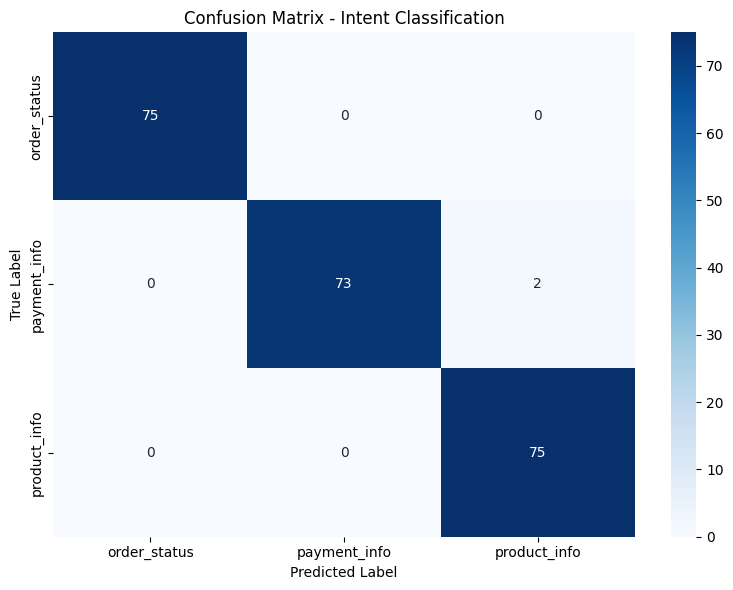

In [ ]:
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
classifier = pipeline(
    "text-classification",
    model="./models/intent_classifier/best_model",
    device=-1
)

# Load test results
test_df = pd.read_csv('./models/intent_classifier/test_results.csv')

print("="*60)
print("📊 DETAILED EVALUATION REPORT")
print("="*60)

# 1. Overall accuracy
accuracy = test_df['correct'].mean()
print(f"\n🎯 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 2. Per-intent accuracy
print("\n📊 Per-Intent Accuracy:")
for intent in test_df['true_label'].unique():
    intent_df = test_df[test_df['true_label'] == intent]
    intent_acc = intent_df['correct'].mean()
    print(f"  {intent}: {intent_acc:.4f} ({intent_acc*100:.2f}%)")

# 3. Error analysis
print("\n❌ Error Analysis (Sample Misclassifications):")
errors = test_df[~test_df['correct']].head(10)
for idx, row in errors.iterrows():
    print(f"\n  Text: '{row['text']}'")
    print(f"  True: {row['true_label']} | Predicted: {row['predicted_label']}")

# 4. Confusion matrix visualization
label2id = {"order_status": 0, "payment_info": 1, "product_info": 2}
y_true = [label2id[l] for l in test_df['true_label']]
y_pred = [label2id[l] for l in test_df['predicted_label']]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()))
plt.title('Confusion Matrix - Intent Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('./evaluation/confusion_matrix.png', dpi=300)
print("\n💾 Confusion matrix saved to ./evaluation/confusion_matrix.png")

# 5. Test with new queries
print("\n" + "="*60)
print("🧪 TESTING WITH NEW QUERIES")
print("="*60)

new_queries = [
    "cek pesanan 555",
    "metode pembayaran apa saja",
    "harga laptop berapa",
    "order 999 udh nyampe blm",
    "bisa bayar pake gopay?",
    "stock kaos ada ga",
]

for query in new_queries:
    result = classifier(query)[0]
    label_id = int(result['label'].split('_')[-1])
    intent = list(label2id.keys())[list(label2id.values()).index(label_id)]
    score = result['score']

    print(f"\n'{query}'")
    print(f"  → {intent} ({score:.3f})")

print("\n✅ Evaluation complete!")

In [ ]:
from transformers import pipeline
import pandas as pd
import json

# Load model
print("Loading model...")
classifier = pipeline(
    "text-classification",
    model="./models/intent_classifier/best_model",
    device=-1
)

# Load label mapping
with open("./models/intent_classifier/best_model/label_mapping.json", 'r') as f:
    label_mapping = json.load(f)
    label2id = label_mapping['label2id']
    id2label = label_mapping['id2label']

print("Model loaded!\n")

# Real-world test cases
real_queries = [
    # Clear cases (should work)
    {"text": "order 123 udah sampai belum", "expected": "order_status"},
    {"text": "bisa bayar pake gopay ga", "expected": "payment_info"},
    {"text": "harga sepatu berapa", "expected": "product_info"},
    {"text": "cek pesanan 456 dong", "expected": "order_status"},
    {"text": "terima cod ga?", "expected": "payment_info"},
    {"text": "stock laptop ada?", "expected": "product_info"},

    # Typo moderate
    {"text": "ordr saya mana", "expected": "order_status"},
    {"text": "bayar pake apa aja sih", "expected": "payment_info"},
    {"text": "hrga kaos brapa", "expected": "product_info"},

    # Typo extreme
    {"text": "ordr sy mn", "expected": "order_status"},
    {"text": "byr pk ap", "expected": "payment_info"},
    {"text": "hrg brp", "expected": "product_info"},

    # Very casual/slang
    {"text": "brg gw mna bro", "expected": "order_status"},
    {"text": "bsa gpay ga sih", "expected": "payment_info"},
    {"text": "ad stok g", "expected": "product_info"},

    # Ambiguous (could be multiple intents)
    {"text": "mau beli sepatu bisa cod ga", "expected": "payment_info"},  # Could be product_info too
    {"text": "orderan belum bayar", "expected": "order_status"},  # Could be payment_info too
    {"text": "harga berapa kalau bayar cash", "expected": "product_info"},  # Could be payment_info

    # Verbose/roundabout
    {"text": "halo min aku mau tanya dong kemarin kan aku udah order terus sekarang itu barangnya udah dikirim belum ya", "expected": "order_status"},
    {"text": "maaf mau nanya nih untuk pembayarannya bisa pakai metode apa aja ya", "expected": "payment_info"},
    {"text": "permisi kak saya tertarik sama produk yang laptop itu harganya berapa ya", "expected": "product_info"},

    # Out of scope (should fail or misclassify)
    {"text": "mau komplain barang rusak", "expected": None},
    {"text": "gimana cara refund", "expected": None},
    {"text": "jam buka toko kapan", "expected": None},
    {"text": "alamat toko dimana", "expected": None},
    {"text": "mau cancel pesanan", "expected": None},
]

print("="*70)
print("🧪 REAL-WORLD QUERY TESTING")
print("="*70)

correct = 0
total = 0
results = []

for item in real_queries:
    text = item['text']
    expected = item['expected']

    # Get prediction
    result = classifier(text)[0]
    predicted = result['label']  # 🔥 Direct label, ga perlu split!
    confidence = result['score']

    is_correct = (predicted == expected)

    if expected is not None:  # Only count in-scope queries
        total += 1
        if is_correct:
            correct += 1

    # Status emoji
    if expected is None:
        status = "⚠️  OUT-OF-SCOPE"
    elif is_correct:
        status = "✅ CORRECT"
    else:
        status = "❌ WRONG"

    print(f"\n{status}")
    print(f"  Query: '{text}'")
    print(f"  Expected: {expected}")
    print(f"  Predicted: {predicted} (confidence: {confidence:.3f})")

    results.append({
        'text': text,
        'expected': expected,
        'predicted': predicted,
        'confidence': confidence,
        'correct': is_correct if expected else None
    })

print("\n" + "="*70)
print("📊 SUMMARY RESULTS")
print("="*70)

if total > 0:
    accuracy = correct / total
    print(f"\n✅ In-scope Accuracy: {correct}/{total} = {accuracy:.2%}")
    print(f"   (Out-of-scope queries not counted)")
else:
    print("\nNo in-scope queries tested")

# Breakdown by category
print("\n📊 Breakdown:")

categories = {
    "Clear queries (easy)": real_queries[0:6],
    "Moderate typos": real_queries[6:9],
    "Extreme typos": real_queries[9:12],
    "Very casual/slang": real_queries[12:15],
    "Ambiguous queries": real_queries[15:18],
    "Verbose queries": real_queries[18:21],
    "Out-of-scope": real_queries[21:],
}

for category, queries in categories.items():
    category_results = [r for r in results if r['text'] in [q['text'] for q in queries]]

    if category == "Out-of-scope":
        print(f"\n  {category}: {len(queries)} queries (not scored)")
    else:
        cat_correct = sum([1 for r in category_results if r['correct'] == True])
        cat_total = len(queries)
        cat_acc = cat_correct / cat_total if cat_total > 0 else 0
        print(f"  {category}: {cat_correct}/{cat_total} = {cat_acc:.0%}")

# Save results
df = pd.DataFrame(results)
df.to_csv('./evaluation/real_world_test_results.csv', index=False)
print("\n💾 Results saved to: ./evaluation/real_world_test_results.csv")

# Error analysis
print("\n" + "="*70)
print("❌ ERROR ANALYSIS")
print("="*70)

errors = df[(df['expected'].notna()) & (df['correct'] == False)]

if len(errors) > 0:
    print(f"\nFound {len(errors)} misclassifications:\n")
    for idx, row in errors.iterrows():
        print(f"  • '{row['text']}'")
        print(f"    Expected: {row['expected']}")
        print(f"    Predicted: {row['predicted']} (confidence: {row['confidence']:.3f})")
        print()
else:
    print("\n🎉 No errors found! All queries classified correctly.")

# Confidence analysis
print("="*70)
print("📊 CONFIDENCE ANALYSIS")
print("="*70)

in_scope = df[df['expected'].notna()]

avg_conf = in_scope['confidence'].mean()
min_conf = in_scope['confidence'].min()
max_conf = in_scope['confidence'].max()

print(f"\nAverage confidence: {avg_conf:.3f}")
print(f"Min confidence: {min_conf:.3f}")
print(f"Max confidence: {max_conf:.3f}")

# Low confidence queries
low_conf_threshold = 0.80
low_conf = in_scope[in_scope['confidence'] < low_conf_threshold]

if len(low_conf) > 0:
    print(f"\n⚠️  Queries with confidence < {low_conf_threshold}:")
    for idx, row in low_conf.iterrows():
        print(f"  • '{row['text']}' → {row['predicted']} ({row['confidence']:.3f})")
else:
    print(f"\n✅ All queries have confidence >= {low_conf_threshold}")

print("\n" + "="*70)
print("✅ TESTING COMPLETE!")
print("="*70)

Loading model...


Device set to use cpu


Model loaded!

🧪 REAL-WORLD QUERY TESTING

✅ CORRECT
  Query: 'order 123 udah sampai belum'
  Expected: order_status
  Predicted: order_status (confidence: 0.999)

✅ CORRECT
  Query: 'bisa bayar pake gopay ga'
  Expected: payment_info
  Predicted: payment_info (confidence: 0.999)

✅ CORRECT
  Query: 'harga sepatu berapa'
  Expected: product_info
  Predicted: product_info (confidence: 0.999)

✅ CORRECT
  Query: 'cek pesanan 456 dong'
  Expected: order_status
  Predicted: order_status (confidence: 0.999)

✅ CORRECT
  Query: 'terima cod ga?'
  Expected: payment_info
  Predicted: payment_info (confidence: 0.999)

✅ CORRECT
  Query: 'stock laptop ada?'
  Expected: product_info
  Predicted: product_info (confidence: 0.999)

✅ CORRECT
  Query: 'ordr saya mana'
  Expected: order_status
  Predicted: order_status (confidence: 0.981)

✅ CORRECT
  Query: 'bayar pake apa aja sih'
  Expected: payment_info
  Predicted: payment_info (confidence: 0.999)

✅ CORRECT
  Query: 'hrga kaos brapa'
  Expected:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Set style untuk grafik
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Create output directory
os.makedirs('./evaluation/figures', exist_ok=True)
os.makedirs('./evaluation/tables', exist_ok=True)

print("="*70)
print("📊 COMPREHENSIVE EVALUATION REPORT")
print("="*70)

# ============================================================
# 1. LOAD MODEL & DATA
# ============================================================

print("\n🔧 Loading model and data...")

# Load model
classifier = pipeline(
    "text-classification",
    model="./models/intent_classifier/best_model",
    device=-1
)

# Load label mapping
with open("./models/intent_classifier/best_model/label_mapping.json", 'r') as f:
    label_mapping = json.load(f)
    label2id = label_mapping['label2id']
    id2label = label_mapping['id2label']

# Load test results (from training)
test_results_df = pd.read_csv('./models/intent_classifier/test_results.csv')

# Load real-world test results (if exists)
if os.path.exists('./evaluation/real_world_test_results.csv'):
    real_world_df = pd.read_csv('./evaluation/real_world_test_results.csv')
    has_real_world = True
else:
    has_real_world = False
    print("⚠️  Real-world test results not found. Run real_world_test.py first.")

print("✅ Data loaded successfully!\n")

# ============================================================
# 2. SYNTHETIC TEST SET EVALUATION
# ============================================================

print("="*70)
print("📊 PART 1: SYNTHETIC TEST SET EVALUATION")
print("="*70)

# Extract predictions and labels
y_true = [label2id[label] for label in test_results_df['true_label']]
y_pred = [label2id[label] for label in test_results_df['predicted_label']]

intent_names = list(label2id.keys())

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print(f"\n✅ Overall Metrics:")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

# Per-class metrics
print(f"\n📊 Per-Class Metrics:")
precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0
)

metrics_df = pd.DataFrame({
    'Intent': intent_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support_per_class
})

print(metrics_df.to_string(index=False))

# Save to CSV
metrics_df.to_csv('./evaluation/tables/synthetic_test_metrics.csv', index=False)
print("\n💾 Saved to: ./evaluation/tables/synthetic_test_metrics.csv")

# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

print("\n" + "="*70)
print("📊 PART 2: CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, y_pred)

print(f"\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=intent_names,
    yticklabels=intent_names,
    cbar_kws={'label': 'Count'},
    ax=ax
)

ax.set_title('Confusion Matrix - Synthetic Test Set', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('./evaluation/figures/confusion_matrix_synthetic.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved to: ./evaluation/figures/confusion_matrix_synthetic.png")
plt.close()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=intent_names,
    yticklabels=intent_names,
    cbar_kws={'label': 'Percentage'},
    ax=ax
)

ax.set_title('Normalized Confusion Matrix - Synthetic Test Set', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('./evaluation/figures/confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
print("💾 Saved to: ./evaluation/figures/confusion_matrix_normalized.png")
plt.close()

# ============================================================
# 4. PER-CLASS PERFORMANCE BAR CHART
# ============================================================

print("\n" + "="*70)
print("📊 PART 3: PER-CLASS PERFORMANCE VISUALIZATION")
print("="*70)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(intent_names))
width = 0.25

bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', color='#e74c3c')

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Intent', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(intent_names, rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('./evaluation/figures/per_class_performance.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved to: ./evaluation/figures/per_class_performance.png")
plt.close()

# ============================================================
# 5. ERROR ANALYSIS - SYNTHETIC DATA
# ============================================================

print("\n" + "="*70)
print("📊 PART 4: ERROR ANALYSIS - SYNTHETIC TEST SET")
print("="*70)

errors_df = test_results_df[test_results_df['correct'] == False]

print(f"\n❌ Total Errors: {len(errors_df)} out of {len(test_results_df)} ({len(errors_df)/len(test_results_df)*100:.2f}%)")

if len(errors_df) > 0:
    print(f"\n🔍 Sample Errors (showing up to 10):\n")
    for i, (idx, row) in enumerate(errors_df.head(10).iterrows(), 1):
        print(f"{i}. Text: '{row['text']}'")
        print(f"   True: {row['true_label']} | Predicted: {row['predicted_label']}")
        print()

    # Error distribution
    error_dist = errors_df.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
    error_dist = error_dist.sort_values('count', ascending=False)

    print("📊 Error Distribution:")
    print(error_dist.to_string(index=False))

    error_dist.to_csv('./evaluation/tables/error_distribution_synthetic.csv', index=False)
    print("\n💾 Saved to: ./evaluation/tables/error_distribution_synthetic.csv")
else:
    print("\n🎉 No errors! Perfect classification on synthetic test set.")

# ============================================================
# 6. REAL-WORLD TEST EVALUATION (if available)
# ============================================================

if has_real_world:
    print("\n" + "="*70)
    print("📊 PART 5: REAL-WORLD TEST EVALUATION")
    print("="*70)

    # Filter in-scope queries
    real_in_scope = real_world_df[real_world_df['expected'].notna()].copy()

    if len(real_in_scope) > 0:
        # Ensure correct is boolean
        real_in_scope['correct'] = real_in_scope['correct'].fillna(False).astype(bool)

        real_accuracy = real_in_scope['correct'].mean()
        correct_count = int(real_in_scope['correct'].sum())
        wrong_count = int(len(real_in_scope) - correct_count)

        print(f"\n✅ Real-World Accuracy: {real_accuracy:.4f} ({real_accuracy*100:.2f}%)")
        print(f"   Total queries: {len(real_in_scope)}")
        print(f"   Correct: {correct_count}")
        print(f"   Wrong: {wrong_count}")

        # Confidence analysis
        print(f"\n📊 Confidence Statistics:")
        print(f"   Mean confidence: {real_in_scope['confidence'].mean():.4f}")
        print(f"   Median confidence: {real_in_scope['confidence'].median():.4f}")
        print(f"   Min confidence: {real_in_scope['confidence'].min():.4f}")
        print(f"   Max confidence: {real_in_scope['confidence'].max():.4f}")

        # Separate correct and wrong queries
        correct_queries = real_in_scope[real_in_scope['correct'] == True]
        wrong_queries = real_in_scope[real_in_scope['correct'] == False]

        if len(correct_queries) > 0:
            correct_conf = correct_queries['confidence']
            print(f"\n   Avg confidence (correct): {correct_conf.mean():.4f}")

        if len(wrong_queries) > 0:
            wrong_conf = wrong_queries['confidence']
            print(f"   Avg confidence (wrong): {wrong_conf.mean():.4f}")

            # Plot confidence distribution
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            # Box plot
            data_to_plot = [correct_conf.tolist(), wrong_conf.tolist()]
            ax1.boxplot(data_to_plot, labels=['Correct', 'Wrong'])
            ax1.set_ylabel('Confidence Score', fontsize=12)
            ax1.set_title('Confidence Distribution by Correctness', fontsize=14, fontweight='bold')
            ax1.grid(axis='y', alpha=0.3)

            # Histogram
            ax2.hist(correct_conf, bins=10, alpha=0.7, label='Correct', color='green', edgecolor='black')
            ax2.hist(wrong_conf, bins=10, alpha=0.7, label='Wrong', color='red', edgecolor='black')
            ax2.set_xlabel('Confidence Score', fontsize=12)
            ax2.set_ylabel('Frequency', fontsize=12)
            ax2.set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
            ax2.legend()
            ax2.grid(axis='y', alpha=0.3)

            plt.tight_layout()
            plt.savefig('./evaluation/figures/confidence_analysis.png', dpi=300, bbox_inches='tight')
            print("\n💾 Saved to: ./evaluation/figures/confidence_analysis.png")
            plt.close()

            # Error analysis
            print(f"\n❌ Real-World Errors ({len(wrong_queries)}):\n")
            for idx, row in wrong_queries.iterrows():
                print(f"• Text: '{row['text']}'")
                print(f"  Expected: {row['expected']} | Predicted: {row['predicted']} (conf: {row['confidence']:.3f})")
                print()

            # Save errors
            wrong_queries.to_csv('./evaluation/tables/real_world_errors.csv', index=False)
            print("💾 Saved to: ./evaluation/tables/real_world_errors.csv")
        else:
            print("\n🎉 No errors in real-world queries! Perfect score!")

# ============================================================
# 7. COMPARISON: SYNTHETIC vs REAL-WORLD
# ============================================================

if has_real_world and len(real_in_scope) > 0:
    print("\n" + "="*70)
    print("📊 PART 6: SYNTHETIC vs REAL-WORLD COMPARISON")
    print("="*70)

    synthetic_acc = accuracy
    real_acc = real_accuracy
    gap = synthetic_acc - real_acc

    print(f"\n📊 Performance Gap Analysis:")
    print(f"   Synthetic Test Accuracy: {synthetic_acc:.4f} ({synthetic_acc*100:.2f}%)")
    print(f"   Real-World Accuracy:     {real_acc:.4f} ({real_acc*100:.2f}%)")
    print(f"   Gap:                     {gap:.4f} ({gap*100:.2f}%)")

    # Bar chart comparison
    fig, ax = plt.subplots(figsize=(8, 6))

    categories = ['Synthetic\nTest Set', 'Real-World\nQueries']
    accuracies = [synthetic_acc, real_acc]
    colors = ['#3498db', '#e74c3c']

    bars = ax.bar(categories, accuracies, color=colors, edgecolor='black', linewidth=1.5)

    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Model Performance: Synthetic vs Real-World', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{acc:.2%}\n({acc:.4f})',
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

    # Add gap annotation
    ax.annotate(
        f'Gap: {gap:.2%}',
        xy=(0.5, (synthetic_acc + real_acc) / 2),
        xytext=(1.3, (synthetic_acc + real_acc) / 2),
        arrowprops=dict(arrowstyle='<->', color='red', lw=2),
        fontsize=12,
        color='red',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig('./evaluation/figures/synthetic_vs_real_comparison.png', dpi=300, bbox_inches='tight')
    print("\n💾 Saved to: ./evaluation/figures/synthetic_vs_real_comparison.png")
    plt.close()

    # Save comparison table
    comparison_df = pd.DataFrame({
        'Dataset': ['Synthetic Test Set', 'Real-World Queries'],
        'Accuracy': [synthetic_acc, real_acc],
        'Num Samples': [len(test_results_df), len(real_in_scope)]
    })

    comparison_df.to_csv('./evaluation/tables/performance_comparison.csv', index=False)
    print("💾 Saved to: ./evaluation/tables/performance_comparison.csv")

# ============================================================
# 8. DATASET STATISTICS
# ============================================================

print("\n" + "="*70)
print("📊 PART 7: DATASET STATISTICS")
print("="*70)

# Load full dataset
full_dataset = pd.read_csv('data/synthetic/intent_dataset.csv')

print(f"\n📊 Dataset Overview:")
print(f"   Total samples: {len(full_dataset)}")
print(f"\n   Intent distribution:")

intent_counts = full_dataset['intent'].value_counts()
for intent, count in intent_counts.items():
    percentage = count / len(full_dataset) * 100
    print(f"     {intent}: {count} ({percentage:.1f}%)")

# Plot intent distribution
fig, ax = plt.subplots(figsize=(8, 6))

intent_counts.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)

ax.set_title('Training Dataset Intent Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Intent', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (intent, count) in enumerate(intent_counts.items()):
    ax.text(i, count, f'{count}\n({count/len(full_dataset)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./evaluation/figures/dataset_distribution.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved to: ./evaluation/figures/dataset_distribution.png")
plt.close()

# Text length analysis
full_dataset['text_length'] = full_dataset['text'].str.len()
full_dataset['word_count'] = full_dataset['text'].str.split().str.len()

print(f"\n📊 Text Statistics:")
print(f"   Avg character length: {full_dataset['text_length'].mean():.1f}")
print(f"   Avg word count: {full_dataset['word_count'].mean():.1f}")
print(f"   Min character length: {full_dataset['text_length'].min()}")
print(f"   Max character length: {full_dataset['text_length'].max()}")

# Plot text length distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Character length
for intent in intent_names:
    intent_data = full_dataset[full_dataset['intent'] == intent]['text_length']
    ax1.hist(intent_data, bins=20, alpha=0.5, label=intent, edgecolor='black')

ax1.set_xlabel('Character Length', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Character Length Distribution by Intent', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Word count
for intent in intent_names:
    intent_data = full_dataset[full_dataset['intent'] == intent]['word_count']
    ax2.hist(intent_data, bins=15, alpha=0.5, label=intent, edgecolor='black')

ax2.set_xlabel('Word Count', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Word Count Distribution by Intent', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./evaluation/figures/text_statistics.png', dpi=300, bbox_inches='tight')
print("💾 Saved to: ./evaluation/figures/text_statistics.png")
plt.close()

# Save statistics
stats_df = pd.DataFrame({
    'Metric': ['Total Samples', 'Avg Char Length', 'Avg Word Count', 'Min Char Length', 'Max Char Length'],
    'Value': [
        len(full_dataset),
        f"{full_dataset['text_length'].mean():.1f}",
        f"{full_dataset['word_count'].mean():.1f}",
        full_dataset['text_length'].min(),
        full_dataset['text_length'].max()
    ]
})

stats_df.to_csv('./evaluation/tables/dataset_statistics.csv', index=False)
print("💾 Saved to: ./evaluation/tables/dataset_statistics.csv")

# ============================================================
# 9. GENERATE SUMMARY REPORT
# ============================================================

print("\n" + "="*70)
print("📊 PART 8: GENERATING SUMMARY REPORT")
print("="*70)

report_lines = []
report_lines.append("="*70)
report_lines.append("EVALUATION SUMMARY REPORT")
report_lines.append("="*70)
report_lines.append("")

report_lines.append("1. DATASET STATISTICS")
report_lines.append("-" * 70)
report_lines.append(f"Total training samples: {len(full_dataset)}")
report_lines.append(f"Intent distribution: {dict(intent_counts)}")
report_lines.append(f"Avg text length: {full_dataset['text_length'].mean():.1f} characters")
report_lines.append(f"Avg word count: {full_dataset['word_count'].mean():.1f} words")
report_lines.append("")

report_lines.append("2. SYNTHETIC TEST SET PERFORMANCE")
report_lines.append("-" * 70)
report_lines.append(f"Test set size: {len(test_results_df)} samples")
report_lines.append(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
report_lines.append(f"Precision: {precision:.4f}")
report_lines.append(f"Recall: {recall:.4f}")
report_lines.append(f"F1-Score: {f1:.4f}")
report_lines.append("")
report_lines.append("Per-class metrics:")
for idx, intent in enumerate(intent_names):
    report_lines.append(f"  {intent}:")
    report_lines.append(f"    Precision: {precision_per_class[idx]:.4f}")
    report_lines.append(f"    Recall: {recall_per_class[idx]:.4f}")
    report_lines.append(f"    F1-Score: {f1_per_class[idx]:.4f}")
report_lines.append("")

if has_real_world and len(real_in_scope) > 0:
    report_lines.append("3. REAL-WORLD TEST PERFORMANCE")
    report_lines.append("-" * 70)
    report_lines.append(f"Test set size: {len(real_in_scope)} queries")
    report_lines.append(f"Overall Accuracy: {real_accuracy:.4f} ({real_accuracy*100:.2f}%)")
    report_lines.append(f"Correct predictions: {correct_count}")
    report_lines.append(f"Wrong predictions: {wrong_count}")
    report_lines.append("")
    report_lines.append(f"Confidence statistics:")
    report_lines.append(f"  Mean: {real_in_scope['confidence'].mean():.4f}")
    report_lines.append(f"  Median: {real_in_scope['confidence'].median():.4f}")
    report_lines.append(f"  Min: {real_in_scope['confidence'].min():.4f}")
    report_lines.append(f"  Max: {real_in_scope['confidence'].max():.4f}")
    report_lines.append("")

    report_lines.append("4. PERFORMANCE GAP ANALYSIS")
    report_lines.append("-" * 70)
    report_lines.append(f"Synthetic test accuracy: {synthetic_acc:.4f} ({synthetic_acc*100:.2f}%)")
    report_lines.append(f"Real-world accuracy: {real_acc:.4f} ({real_acc*100:.2f}%)")
    report_lines.append(f"Performance gap: {gap:.4f} ({gap*100:.2f}%)")
    report_lines.append("")

report_lines.append("5. GENERATED FILES")
report_lines.append("-" * 70)
report_lines.append("Figures:")
report_lines.append("  - confusion_matrix_synthetic.png")
report_lines.append("  - confusion_matrix_normalized.png")
report_lines.append("  - per_class_performance.png")
report_lines.append("  - dataset_distribution.png")
report_lines.append("  - text_statistics.png")
if has_real_world and len(real_in_scope) > 0 and wrong_count > 0:
    report_lines.append("  - confidence_analysis.png")
    report_lines.append("  - synthetic_vs_real_comparison.png")
report_lines.append("")
report_lines.append("Tables:")
report_lines.append("  - synthetic_test_metrics.csv")
if len(errors_df) > 0:
    report_lines.append("  - error_distribution_synthetic.csv")
report_lines.append("  - dataset_statistics.csv")
if has_real_world and len(real_in_scope) > 0:
    if wrong_count > 0:
        report_lines.append("  - real_world_errors.csv")
    report_lines.append("  - performance_comparison.csv")
report_lines.append("")

report_lines.append("="*70)
report_lines.append("END OF REPORT")
report_lines.append("="*70)

# Save report
report_text = "\n".join(report_lines)
with open('./evaluation/EVALUATION_REPORT.txt', 'w') as f:
    f.write(report_text)

print("\n💾 Summary report saved to: ./evaluation/EVALUATION_REPORT.txt")

# Print report
print("\n" + report_text)

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)
print("\n📁 All files saved in:")
print("   - ./evaluation/figures/  (PNG images)")
print("   - ./evaluation/tables/   (CSV files)")
print("   - ./evaluation/EVALUATION_REPORT.txt")
print("\n🎉 Ready for your thesis!")

📊 COMPREHENSIVE EVALUATION REPORT

🔧 Loading model and data...


Device set to use cpu


✅ Data loaded successfully!

📊 PART 1: SYNTHETIC TEST SET EVALUATION

✅ Overall Metrics:
   Accuracy:  0.9911 (99.11%)
   Precision: 0.9913
   Recall:    0.9911
   F1-Score:  0.9911

📊 Per-Class Metrics:
      Intent  Precision   Recall  F1-Score  Support
order_status   1.000000 1.000000  1.000000       75
payment_info   1.000000 0.973333  0.986486       75
product_info   0.974026 1.000000  0.986842       75

💾 Saved to: ./evaluation/tables/synthetic_test_metrics.csv

📊 PART 2: CONFUSION MATRIX

Confusion Matrix:
[[75  0  0]
 [ 0 73  2]
 [ 0  0 75]]

💾 Saved to: ./evaluation/figures/confusion_matrix_synthetic.png
💾 Saved to: ./evaluation/figures/confusion_matrix_normalized.png

📊 PART 3: PER-CLASS PERFORMANCE VISUALIZATION

💾 Saved to: ./evaluation/figures/per_class_performance.png

📊 PART 4: ERROR ANALYSIS - SYNTHETIC TEST SET

❌ Total Errors: 2 out of 225 (0.89%)

🔍 Sample Errors (showing up to 10):

1. Text: 'min ada metde ovo? pls'
   True: payment_info | Predicted: product_info

2

In [ ]:
import shutil

# Zip model folder
shutil.make_archive('intent_classifier_model', 'zip', './models/intent_classifier/best_model')

print("✅ Model zipped!")
print("📥 Download file: intent_classifier_model.zip")

✅ Model zipped!
📥 Download file: intent_classifier_model.zip
